[fetch_atlas_harvard_oxford] Dataset found in /home/vm5631/nilearn_data/fsl

0 Background
1 Frontal Pole
2 Insular Cortex
3 Superior Frontal Gyrus
4 Middle Frontal Gyrus
5 Inferior Frontal Gyrus, pars triangularis
6 Inferior Frontal Gyrus, pars opercularis
7 Precentral Gyrus
8 Temporal Pole
9 Superior Temporal Gyrus, anterior division
10 Superior Temporal Gyrus, posterior division
11 Middle Temporal Gyrus, anterior division
12 Middle Temporal Gyrus, posterior division
13 Middle Temporal Gyrus, temporooccipital part
14 Inferior Temporal Gyrus, anterior division
15 Inferior Temporal Gyrus, posterior division
16 Inferior Temporal Gyrus, temporooccipital part
17 Postcentral Gyrus
18 Superior Parietal Lobule
19 Supramarginal Gyrus, anterior division
20 Supramarginal Gyrus, posterior division
21 Angular Gyrus
22 Lateral Occipital Cortex, superior division
23 Lateral Occipital Cortex, inferior division
24 Intracalcarine Cortex
25 Frontal Medial Cortex
26 Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex)
27 Subcallosal Cortex
28 Paracingulate Gyrus
29

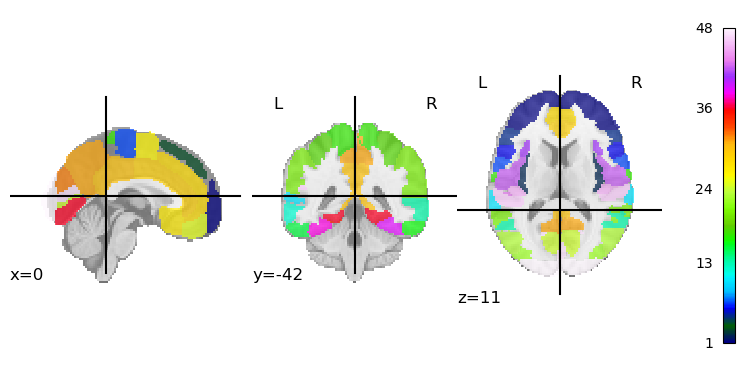

In [1]:
from nilearn import datasets, image, plotting
import nibabel as nib
import numpy as np
import os


# Fetch atlas
atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
plotting.plot_roi(atlas.maps)
atlas_data = atlas.maps.get_fdata()
labels = atlas.labels

for i, label in enumerate(labels):
    print(i, label)

[fetch_atlas_harvard_oxford] Dataset found in /home/vm5631/nilearn_data/fsl

0 Background
1 Left Cerebral White Matter
2 Left Cerebral Cortex
3 Left Lateral Ventricle
4 Left Thalamus
5 Left Caudate
6 Left Putamen
7 Left Pallidum
8 Brain-Stem
9 Left Hippocampus
10 Left Amygdala
11 Left Accumbens
12 Right Cerebral White Matter
13 Right Cerebral Cortex
14 Right Lateral Ventricle
15 Right Thalamus
16 Right Caudate
17 Right Putamen
18 Right Pallidum
19 Right Hippocampus
20 Right Amygdala
21 Right Accumbens


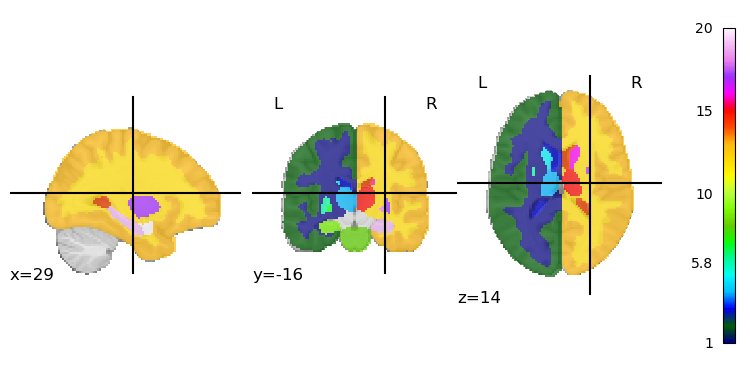

In [2]:
# Fetch atlas
sub_atlas = datasets.fetch_atlas_harvard_oxford('sub-maxprob-thr25-2mm')
plotting.plot_roi(sub_atlas.maps)
sub_atlas_data = sub_atlas.maps.get_fdata()
sub_labels = sub_atlas.labels

for i, label in enumerate(sub_labels):
    print(i, label)

In [3]:
# NVM FOR NOW
# dir_nilearn = "/home/NEU480/datasets/nilearn_data"
# atlas_basc = datasets.fetch_atlas_basc_multiscale_2015(n_rois=325, )
# plotting.plot_roi(atlas.maps)
# atlas_data = atlas.maps.get_fdata()
# labels = atlas.labels

# for i, label in enumerate(labels):
#     print(i, label)

[fetch_atlas_destrieux_2009] Dataset found in /home/vm5631/nilearn_data/destrieux_2009

/tmp/ipykernel_338193/543288151.py:2: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index          name
    42 L Medial_wall
   117 R Medial_wall

  destrieux_atlas = datasets.fetch_atlas_destrieux_2009()


0 Background
1 L G_and_S_frontomargin
2 L G_and_S_occipital_inf
3 L G_and_S_paracentral
4 L G_and_S_subcentral
5 L G_and_S_transv_frontopol
6 L G_and_S_cingul-Ant
7 L G_and_S_cingul-Mid-Ant
8 L G_and_S_cingul-Mid-Post
9 L G_cingul-Post-dorsal
10 L G_cingul-Post-ventral
11 L G_cuneus
12 L G_front_inf-Opercular
13 L G_front_inf-Orbital
14 L G_front_inf-Triangul
15 L G_front_middle
16 L G_front_sup
17 L G_Ins_lg_and_S_cent_ins
18 L G_insular_short
19 L G_occipital_middle
20 L G_occipital_sup
21 L G_oc-temp_lat-fusifor
22 L G_oc-temp_med-Lingual
23 L G_oc-temp_med-Parahip
24 L G_orbital
25 L G_pariet_inf-Angular
26 L G_pariet_inf-Supramar
27 L G_parietal_sup
28 L G_postcentral
29 L G_precentral
30 L G_precuneus
31 L G_rectus
32 L G_subcallosal
33 L G_temp_sup-G_T_transv
34 L G_temp_sup-Lateral
35 L G_temp_sup-Plan_polar
36 L G_temp_sup-Plan_tempo
37 L G_temporal_inf
38 L G_temporal_middle
39 L Lat_Fis-ant-Horizont
40 L Lat_Fis-ant-Vertical
41 L Lat_Fis-post
42 L Medial_wall
43 L Pole_occip

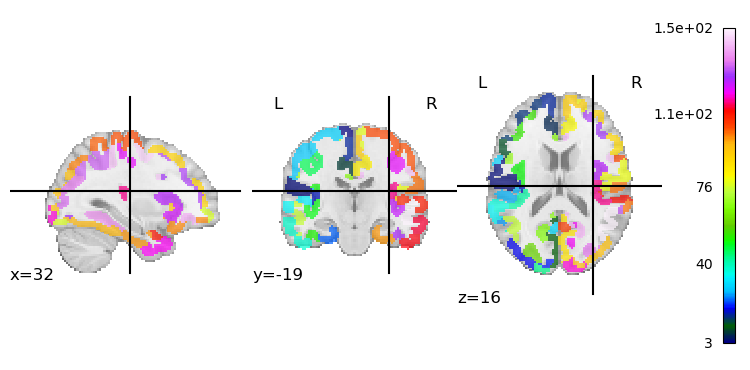

In [3]:
# Fetch atlas
destrieux_atlas = datasets.fetch_atlas_destrieux_2009()
plotting.plot_roi(destrieux_atlas.maps)
destrieux_labels = destrieux_atlas.labels

for i, label in enumerate(destrieux_labels):
    print(i, label)

In [5]:
def make_mask_from_labels(atlas_img, labels_list, atlas_labels, out_path):
    atlas_data = atlas_img.get_fdata()
    selected_indices = [i for i, lab in enumerate(atlas_labels) if lab in labels_list]
    
    if len(selected_indices) == 0:
        raise ValueError(f"No atlas labels found for {labels_list}")
    
    mask_data = np.isin(atlas_data, selected_indices).astype(np.int8)
    mask_img = nib.Nifti1Image(mask_data, atlas_img.affine, atlas_img.header)
    nib.save(mask_img, out_path)
    return mask_img

In [2]:
# This is your personal scratch directory
net_id = os.environ['USER']  # make sure this is your netid
scratch_folder = f"/scratch/network/{net_id}/"

# Make a directory to store your preprocessed data.
roi_dir = scratch_folder + "thesis/roi_masks"
print(f"Data path: {roi_dir}")
os.makedirs(roi_dir, exist_ok=True)

# Take a quick look at the directory structure we created.
!ls -l $roi_dir

Data path: /scratch/network/vm5631/thesis/roi_masks
total 184
-rw-r--r-- 1 vm5631 student  5899 Mar 30 15:55 bilateral_stg.nii.gz
-rw-r--r-- 1 vm5631 student   357 Mar 30 17:47 fetch_destrieux.py
-rw-r--r-- 1 vm5631 student  4548 Mar 30 16:00 heschl.nii.gz
-rw-r--r-- 1 vm5631 student  6147 Mar 30 16:03 itg.nii.gz
-rw-r--r-- 1 vm5631 student  9857 Mar 30 17:32 l_heschl.nii.gz
-rw-r--r-- 1 vm5631 student 11514 Mar 30 17:35 l_mfg.nii.gz
-rw-r--r-- 1 vm5631 student 10360 Mar 30 17:12 l_temp_pole.nii.gz
-rw-r--r-- 1 vm5631 student  6824 Mar 30 15:56 mfg.nii.gz
-rw-r--r-- 1 vm5631 student  6904 Mar 30 16:00 mtg.nii.gz
-rw-r--r-- 1 vm5631 student 10602 Mar 30 17:31 pcc.nii.gz
-rw-r--r-- 1 vm5631 student  6259 Mar 30 17:56 precuneus.nii.gz
-rw-r--r-- 1 vm5631 student 10921 Mar 30 17:45 r_itg.nii.gz
-rw-r--r-- 1 vm5631 student 11490 Mar 30 17:35 r_mfg.nii.gz
-rw-r--r-- 1 vm5631 student 11252 Mar 30 17:46 r_mtg.nii.gz
-rw-r--r-- 1 vm5631 student 13088 Mar 30 16:52 sts.nii.gz
-rw-r--r-- 1 vm5631 

In [49]:
labels_list = ["Precuneous Cortex"]
make_mask_from_labels(
    atlas.maps,
    labels_list=labels_list,
    atlas_labels=labels,
    out_path= roi_dir + "/precuneus.nii.gz"
)

In [44]:
labels_list = ["R G_rectus", "L G_rectus",  "R G_orbital",  "L G_orbital", ]
make_mask_from_labels(
    image.load_img(destrieux_atlas.maps),
    labels_list=labels_list,
    atlas_labels=destrieux_labels,
    out_path= roi_dir + "/vmpfc.nii.gz"
)